In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
matches = pd.read_csv("/content/matches.csv")
deliveries = pd.read_csv("/content/deliveries.csv")

print("Matches dataset:")
print(matches.head())

print("\nDeliveries dataset:")
print(deliveries.head())

Matches dataset:
   id  season       city        date                        team1  \
0   1    2017  Hyderabad  2017-04-05          Sunrisers Hyderabad   
1   2    2017       Pune  2017-04-06               Mumbai Indians   
2   3    2017     Rajkot  2017-04-07                Gujarat Lions   
3   4    2017     Indore  2017-04-08       Rising Pune Supergiant   
4   5    2017  Bangalore  2017-04-08  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         field   
4             Delhi Daredevils  Royal Challengers Bangalore           bat   

   result  dl_applied                       winner  win_by_runs  \
0  normal           0          Sunrise

In [3]:
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

print("\nMatches columns:")
print(matches.columns.tolist())

print("\nDeliveries columns:")
print(deliveries.columns.tolist())

Matches shape: (756, 18)
Deliveries shape: (179078, 21)

Matches columns:
['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']

Deliveries columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder']


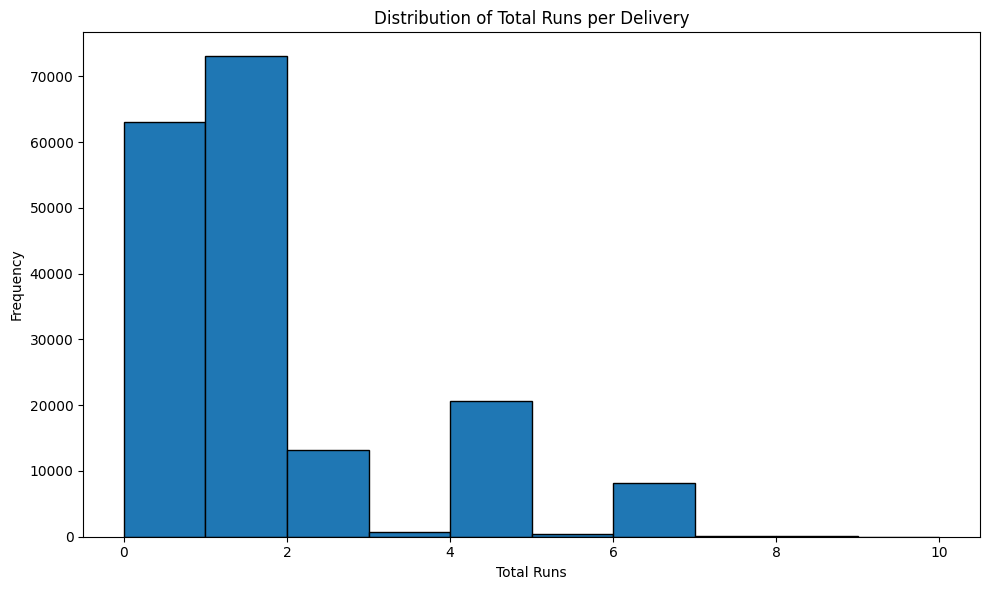

Histogram saved as histogram_total_runs.png


In [4]:
plt.figure(figsize=(10, 6))

plt.hist(deliveries["total_runs"], bins=10, edgecolor="black")

plt.title("Distribution of Total Runs per Delivery")
plt.xlabel("Total Runs")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("histogram_total_runs.png", dpi=300)
plt.show()

print("Histogram saved as histogram_total_runs.png")

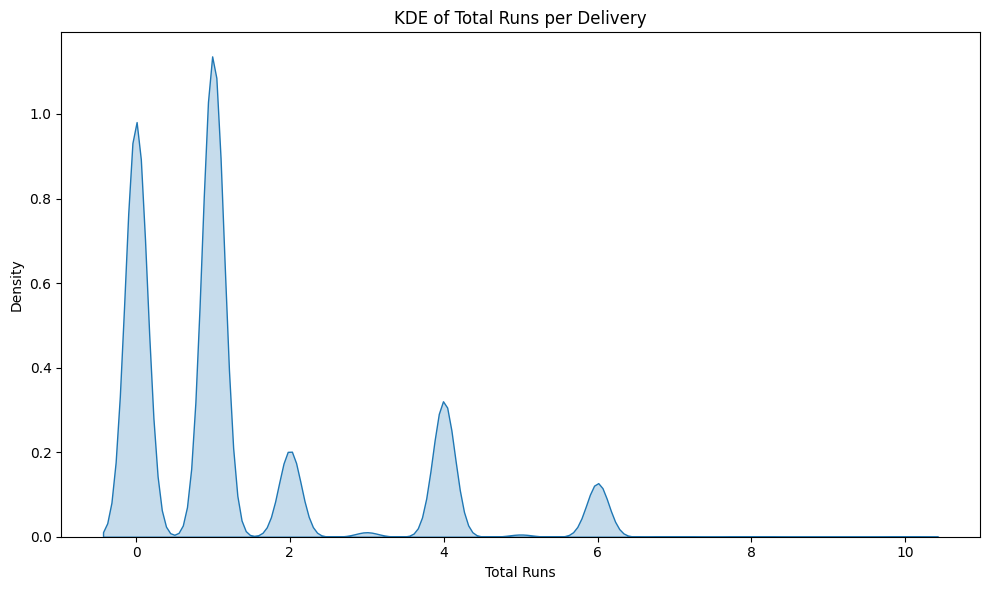

KDE plot saved as kde_total_runs.png


In [5]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    deliveries["total_runs"],
    fill=True
)

plt.title("KDE of Total Runs per Delivery")
plt.xlabel("Total Runs")
plt.ylabel("Density")

plt.tight_layout()
plt.savefig("kde_total_runs.png", dpi=300)
plt.show()

print("KDE plot saved as kde_total_runs.png")

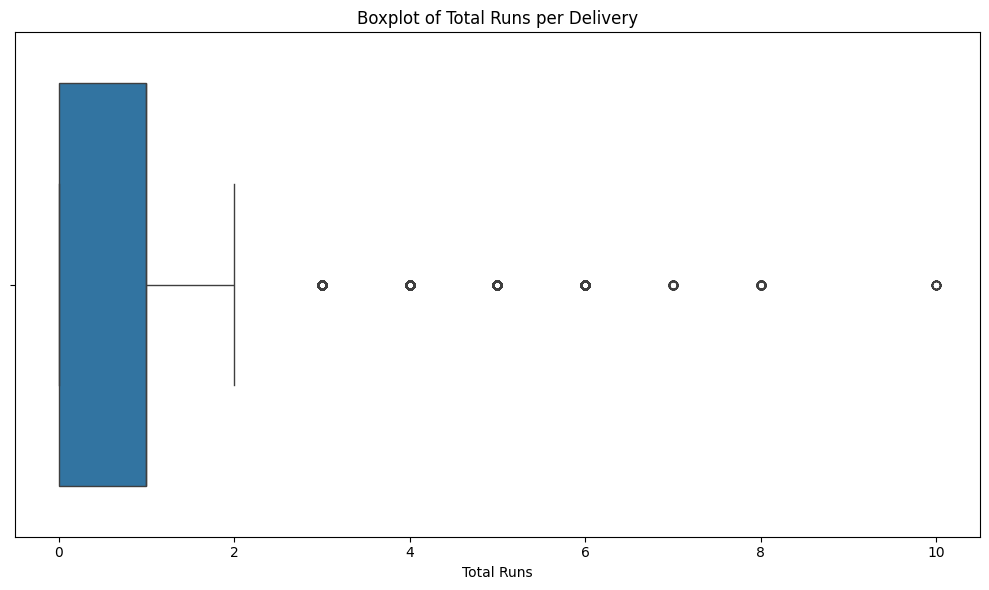

Boxplot saved as boxplot_total_runs.png


In [6]:
plt.figure(figsize=(10, 6))

sns.boxplot(x=deliveries["total_runs"])

plt.title("Boxplot of Total Runs per Delivery")
plt.xlabel("Total Runs")

plt.tight_layout()
plt.savefig("boxplot_total_runs.png", dpi=300)
plt.show()

print("Boxplot saved as boxplot_total_runs.png")

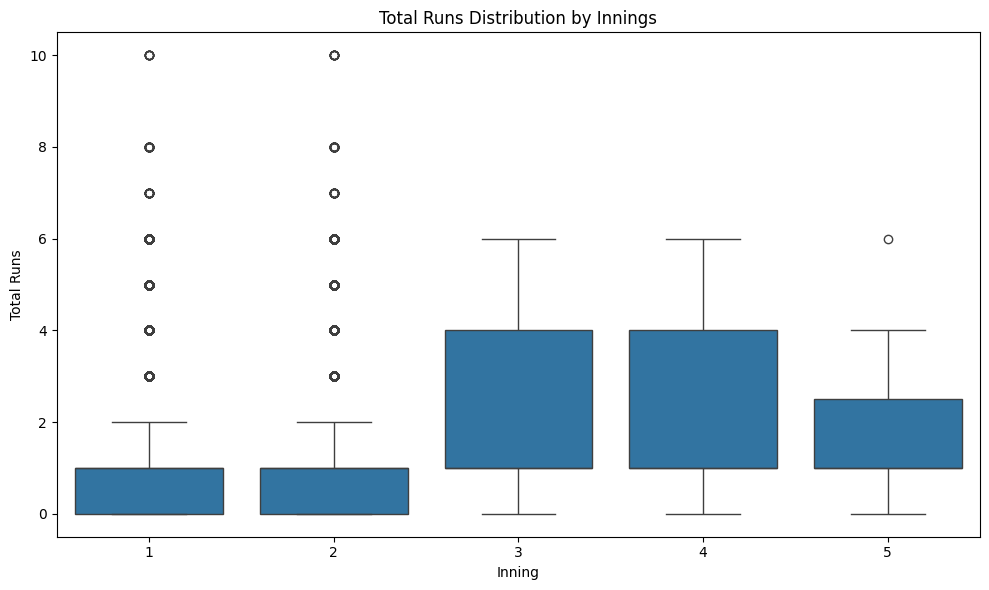

Group comparison plot saved as boxplot_runs_by_inning.png


In [7]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=deliveries,
    x="inning",
    y="total_runs"
)

plt.title("Total Runs Distribution by Innings")
plt.xlabel("Inning")
plt.ylabel("Total Runs")

plt.tight_layout()
plt.savefig("boxplot_runs_by_inning.png", dpi=300)
plt.show()

print("Group comparison plot saved as boxplot_runs_by_inning.png")

In [8]:
Q1 = deliveries["total_runs"].quantile(0.25)
Q3 = deliveries["total_runs"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = deliveries[
    (deliveries["total_runs"] < lower_bound) |
    (deliveries["total_runs"] > upper_bound)
]

print("Statistical Summary of Total Runs")
print("--------------------------------")
print("Mean:", deliveries["total_runs"].mean())
print("Median:", deliveries["total_runs"].median())
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Statistical Summary of Total Runs
--------------------------------
Mean: 1.313896737734395
Median: 1.0
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower bound: -1.5
Upper bound: 2.5
Number of outliers: 29892


In [9]:
skewness = deliveries["total_runs"].skew()

print("Skewness of Total Runs:", skewness)

if skewness > 0:
    print("Interpretation: The distribution is right-skewed.")
elif skewness < 0:
    print("Interpretation: The distribution is left-skewed.")
else:
    print("Interpretation: The distribution is approximately symmetric.")

Skewness of Total Runs: 1.5569328280707322
Interpretation: The distribution is right-skewed.


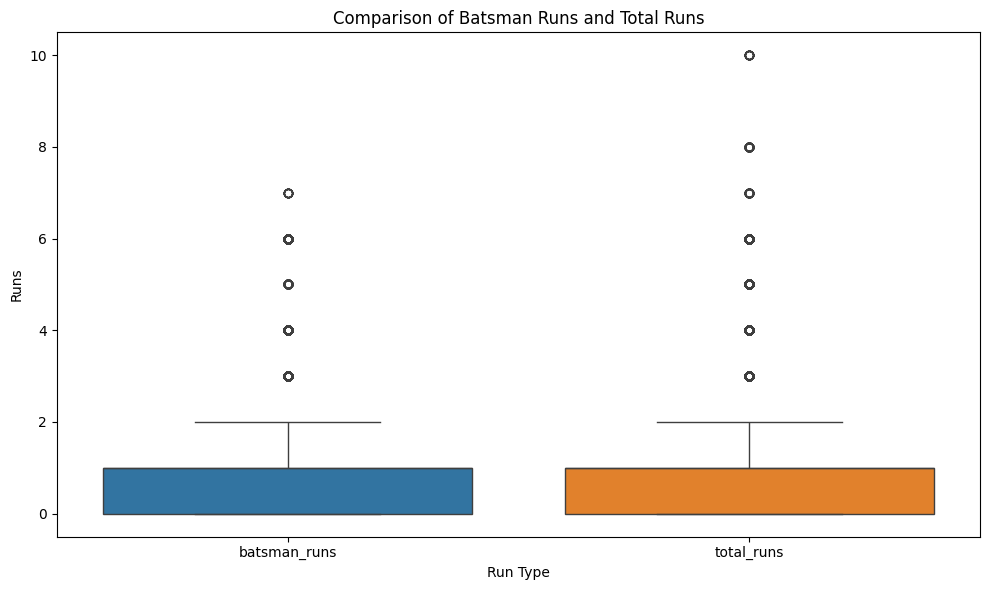

Comparison plot saved as boxplot_batsman_vs_total_runs.png


In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=deliveries[["batsman_runs", "total_runs"]]
)

plt.title("Comparison of Batsman Runs and Total Runs")
plt.xlabel("Run Type")
plt.ylabel("Runs")

plt.tight_layout()
plt.savefig("boxplot_batsman_vs_total_runs.png", dpi=300)
plt.show()

print("Comparison plot saved as boxplot_batsman_vs_total_runs.png")

## Interpretation

The statistical plots show that IPL delivery-level total runs are concentrated at lower values, with most deliveries producing 0 to 2 runs. The histogram and KDE plot show a right-skewed distribution, which is confirmed by the skewness value of 1.56. The boxplot identifies higher run values as potential outliers using the IQR method. The group comparison by innings shows differences in the spread of total runs across innings. Overall, the distributions have a relatively small central spread but contain higher run values that extend the distribution toward the right.

## Project Summary

This project analyzed the distribution of IPL delivery-level runs using statistical visualization techniques.

### Visualizations Created

- Histogram of total runs
- KDE plot of total runs
- Boxplot of total runs
- Boxplot comparing total runs across innings
- Boxplot comparing batsman runs and total runs

### Key Findings

- Mean total runs: 1.31
- Median total runs: 1.00
- IQR: 1.00
- Skewness: 1.56
- The distribution is right-skewed.
- The IQR method identified 29,892 potential outliers.

### Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab